In [23]:
# ======================
# Import Libraries
# ======================
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# Load Dataset
# ======================
df = pd.read_csv('../data/customer_data.csv')

# ======================
# Additional Settings
# ======================
# Display settings
pd.set_option('display.max_columns', None)
# Visualization style
sns.set_style('whitegrid')

# ======================
# Preview Dataset
# ======================
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# ======================
# Data Understanding
# ======================

In [3]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
# Statistical summary
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
# ======================
# Data Cleaning
# ======================

In [5]:
# Check missing values
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# ======================
# Exploratory Data Analysis
# ======================

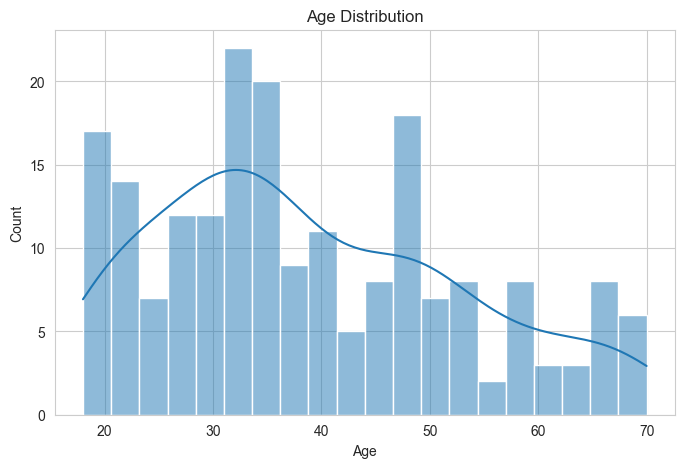

In [7]:
# Age distribution

plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

### Insight

- Most customers are between 25 and 40 years old.
- Customer distribution decreases gradually after age 50.
- The customer base is dominated by young adult consumers.

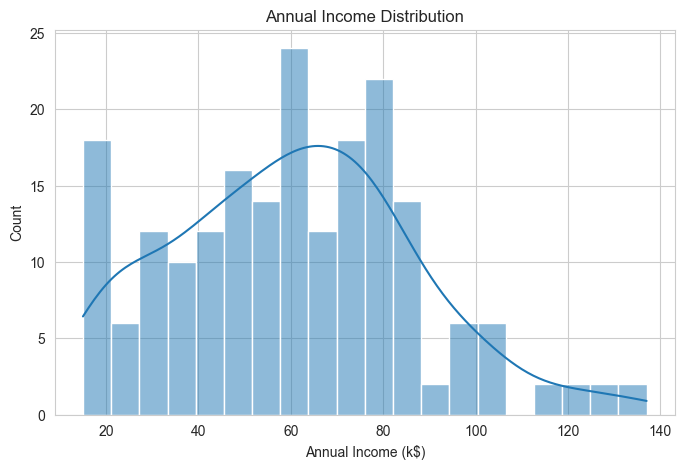

In [8]:
# Annual income distribution

plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)

plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Count')

plt.show()

### Insight

- Most customers fall within the middle-income range (40k–80k).
- A smaller group of high-income customers exists above 100k.
- The income distribution is slightly right-skewed, indicating income diversity among customers.

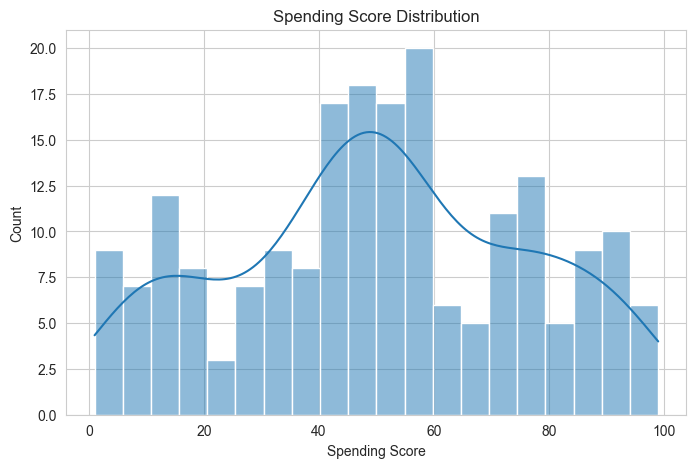

In [9]:
# Spending score distribution

plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)

plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Count')

plt.show()

### Insight

- Most customers have moderate spending scores between 40 and 60.
- A group of high-spending customers exists above 80.
- Spending behavior is relatively diverse across customers.

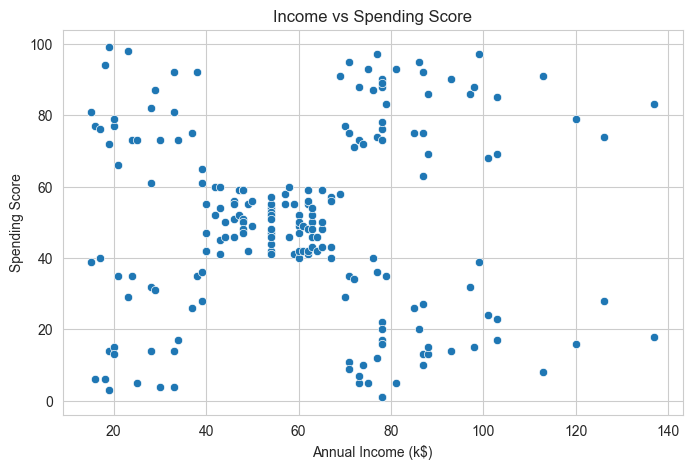

In [32]:
# Income vs Spending Score

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title('Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')

plt.savefig('../output/income_vs_spending.png')

plt.show()

### Insight

- High income does not always correlate with high spending behavior.
- A premium customer segment exists with both high income and high spending scores.
- Some high-income customers show low spending behavior, indicating potential upselling opportunities.
- The majority of customers fall within the middle-income and middle-spending segment.

In [ ]:
# ======================
# Customer Segmentation
# ======================

In [11]:
# Create customer segments

def segment_customer(score):
    if score >= 70:
        return 'High Value'
    elif score >= 40:
        return 'Mid Value'
    else:
        return 'Low Value'

df['Customer Segment'] = df['Spending Score (1-100)'].apply(segment_customer)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Customer Segment
0,1,Male,19,15,39,Low Value
1,2,Male,21,15,81,High Value
2,3,Female,20,16,6,Low Value
3,4,Female,23,16,77,High Value
4,5,Female,31,17,40,Mid Value


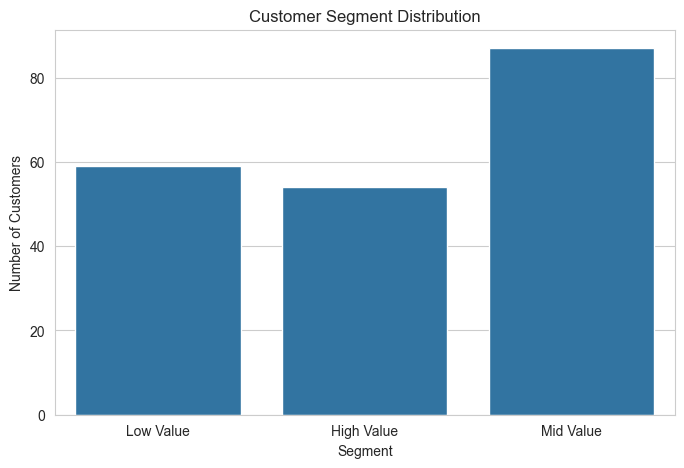

In [12]:
# Customer segment distribution

plt.figure(figsize=(8,5))

sns.countplot(
    x='Customer Segment',
    data=df
)

plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

plt.show()

### Insight

- Mid-value customers represent the largest customer segment.
- High-value customers form a smaller but potentially more profitable segment.
- A considerable number of low-value customers may require engagement or retention strategies.

In [ ]:
# ======================
# KMeans Clustering
# ======================

In [14]:
from sklearn.cluster import KMeans

In [15]:
# Select features for clustering

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


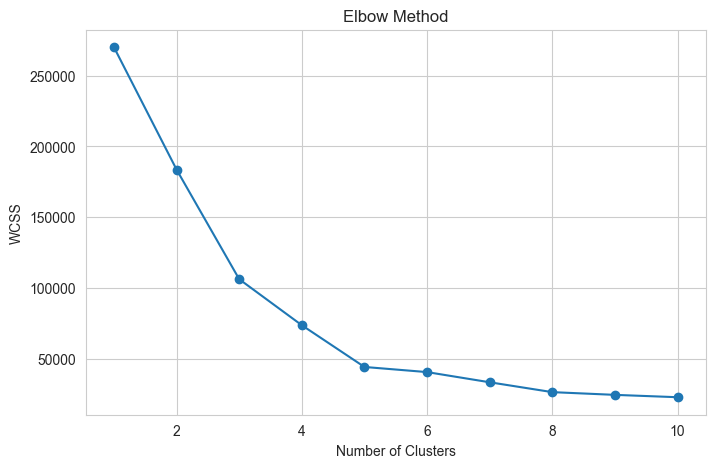

In [31]:
# Elbow Method

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.savefig('../output/elbow_method.png')

plt.show()

In [17]:
# Apply KMeans clustering

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

y_kmeans

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [25]:
# Add cluster labels to dataset

df['Cluster'] = y_kmeans

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [29]:
# Rename cluster labels

cluster_names = {
    0: 'Average Customers',
    1: 'Premium Customers',
    2: 'Young Spenders',
    3: 'Careful Customers',
    4: 'Low Engagement'
}

df['Cluster Name'] = df['Cluster'].map(cluster_names)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Cluster Name
0,1,Male,19,15,39,4,Low Engagement
1,2,Male,21,15,81,2,Young Spenders
2,3,Female,20,16,6,4,Low Engagement
3,4,Female,23,16,77,2,Young Spenders
4,5,Female,31,17,40,4,Low Engagement


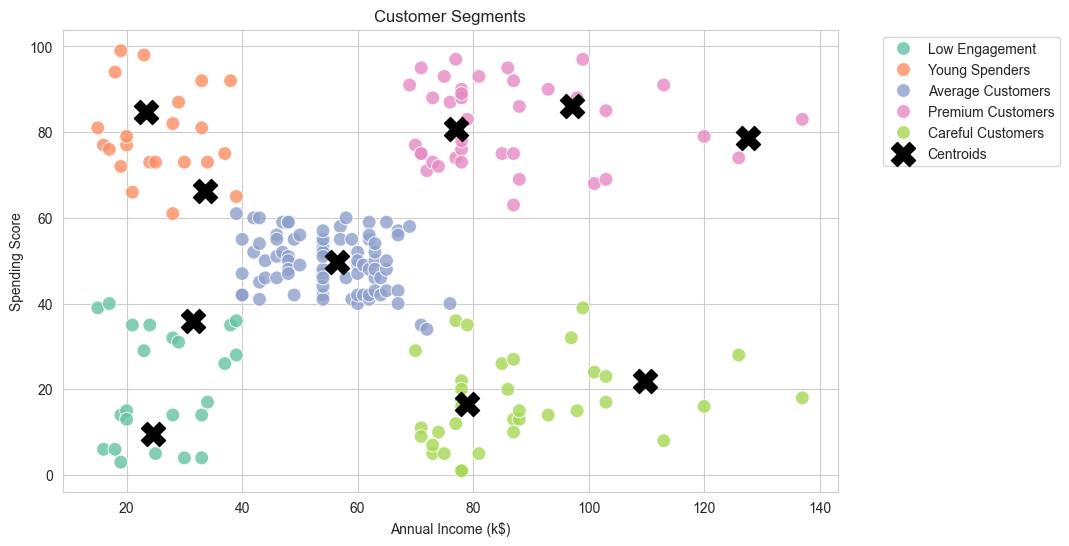

In [34]:
# Visualize customer clusters

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster Name',
    palette='Set2',
    data=df,
    alpha=0.8,
    s=100
)

# Add centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('../output/customer_segments.png')

plt.show()

## Final Business Insights

- Five distinct customer segments were identified using KMeans clustering.
- Premium customers with high income and high spending behavior represent the most valuable segment.
- Some high-income customers demonstrate low spending behavior, indicating opportunities for targeted marketing campaigns.
- Middle-income and middle-spending customers form the largest customer group.
- Clustering analysis helps businesses better understand customer behavior and improve marketing strategies.

# Conclusion

This project analyzed mall customer behavior using exploratory data analysis and KMeans clustering.

Key findings:
- Most customers belong to the middle-income and moderate-spending segment.
- Premium customers with high income and high spending represent a valuable target market.
- Several high-income customers demonstrate low spending behavior, indicating potential upselling opportunities.

KMeans clustering successfully identified five distinct customer groups that can support marketing and customer retention strategies.

In [ ]:
# =====================
# Export Final Dataset
# =====================

In [35]:
df.to_csv('../output/customer_segments.csv', index=False)